In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import jax
import matplotlib.pyplot as plt
import matplotlib
import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger
from flax import serialization

from schmitt_tdvp_overdispersed import TDVPSchmittOverdispersed
from schmitt_tdvp import TDVPSchmitt

from tfim_exact_majorana import run_ed
import numpy as np

import os
import matplotlib.pyplot as plt

import sys

sys.path.append("../src")

import jax.numpy as jnp

import warnings
warnings.filterwarnings("error", category=jnp.ComplexWarning)


W0623 10:44:33.215590 2882795 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0623 10:44:33.217537 2880798 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


∣NK⟩ Tip: You must cite NetKet according to our policy. Use nk.cite() to find out how.

In [5]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)


def main(N, n_samples_tvmc, driver_type, a, alpha, load_parameter_path=None, t0=0.0, extra_str="", stop_time=1.0):
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
    def stop_callback(step,log,driver):
        return driver.t<stop_time
    def get_model():
        return nk.models.RBM(
            alpha=alpha,
            param_dtype=complex,
        )

    def get_vstate(n_samples, power=2):
        seed = 300
        model = get_model()
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples, machine_pow=power
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
        )

        # zero everything
        pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

        W = pars["Dense"]["kernel"]
        a = pars["visible_bias"]
        b = pars["Dense"]["bias"]
        n = hilbert.size
        # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
        #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
        #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
        W = W.at[:, 0].set(-1j * (np.pi / 4))
        b = b.at[0].set(1j * (np.pi / 4) * n)
        # Repeat to get rid of sign since now
        # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
        #   -> even x: 1
        #   -> odd x: 0
        W = W.at[:, 1].set(-1j * (np.pi / 4))
        b = b.at[1].set(1j * (np.pi / 4) * n)
        # Unit 3 left as zero (neutral)
        pars["Dense"]["kernel"] = W
        pars["Dense"]["bias"] = (
            b + (1 + 1j) * jax.random.uniform(jax.random.key(100), b.shape) * 1e-4
        )
        pars["visible_bias"] = (
            jnp.zeros_like(pars["visible_bias"])
            + (1 + 1j) * jax.random.uniform(jax.random.key(100), a.shape) * N * 1e-4
        )

        # visible_bias stays zero
        vstate.parameters = pars
        return vstate

    # Check energy and parity
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx - sigma_z
    # Hamiltonian
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-1.0, J=1.0)

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z) # calculated with samples drawn from psi^2
        return True

    T = 2.0
    save_times = np.linspace(0.0, T, 40)
    if driver_type == "alpha":
        exp_name = f"alpha_{n_samples_tvmc}_{a:1.2f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/RBM_{alpha}/{extra_str}{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    resumed = False
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
            resumed = True
    else:
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    vstate = get_vstate(n_samples_tvmc)
    vstate_alpha = get_vstate(n_samples_tvmc, power=a)
    if resumed:
        assert logger.restore_state(vstate)
        # vstate_alpha params are re-synced from vstate by the driver each step.
        T = T - t0
    elif load_parameter_path is not None:
        # Hotstart from another run's snapshot (first run only).
        with open(
            load_parameter_path,
            "rb",
        ) as infile:
            binary_data = infile.read()
            vstate.variables = serialization.from_bytes(vstate.variables, binary_data)
            vstate.variables = jax.tree.map(lambda x: jnp.array(x), vstate.variables)
            # sampler state
            vstate_alpha.variables = serialization.from_bytes(vstate_alpha.variables, binary_data)
            vstate_alpha.variables = jax.tree.map(lambda x: jnp.array(x), vstate_alpha.variables)
        T = T - t0


    # Callbacks
    callbacks = []
    callbacks.append(stop_callback)
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(acceptance_rate_callback)
    if driver_type == "alpha":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # Set up dynamics
    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}

    # Thermalize
    for i in range(100):
        vstate.sample()
        vstate_alpha.sample()
    if driver_type == "alpha":
        dynamics = TDVPSchmittOverdispersed(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            alpha=a,
            sampling_state=vstate_alpha,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [6]:
for a in (
    0.5,
    1.0,
):
    main(8, 2**12, "alpha", a, alpha=4, stop_time=2.0)

    load_path = (
        f"./data/TFIM_{8}_parity/RBM_{4}/blur_{2**12}_{0.5:1.2f}/log_params_1.mpack"
    )
    main(
        8,
        2**12,
        "alpha",
        a,
        alpha=4,
        load_parameter_path=load_path,
        t0=0.05,
        extra_str="hotstart_",
        stop_time=2.0,
    )


Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...


[       nan 0.99999788 0.99999785 ... 0.16616748 0.16526734 0.16550322]
[       nan 0.99999905 0.99999905 ... 0.54214943 0.53151823 0.53193066]


/tmp/ipykernel_2880798/1571307655.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


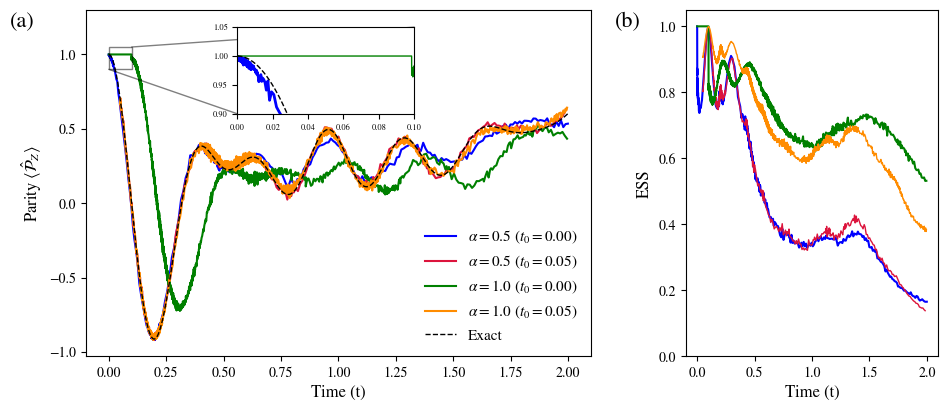

: 

In [ ]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
N, alpha_rbm, n_samples = 8, 4, 2**12
times_exact, parity_exact = run_ed(N, h=1.0, J=1.0, T=2.0)

fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 2, wspace=0.25, width_ratios=[2, 1])
ax_z = fig.add_subplot(gs[0])
ax_ess = fig.add_subplot(gs[1])

ax_inset = ax_z.inset_axes([0.3, 0.7, 0.35, 0.25])
colors = ['blue', 'crimson', 'green', 'darkorange']
t = 2.0
inset_xlim = [0.0, 0.1]
inset_ylim = [0.9, 1.05]

for i, a in enumerate([0.5, 1.0]):
    # cold start
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha_rbm}/alpha_{n_samples}_{a:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        print(ess)
        ax_z.plot(ts, par, color=colors[2*i], label=fr"$\alpha={a}$ ($t_0=0.00$)")
        ax_inset.plot(ts, par, color=colors[2*i], lw=2 if i == 0 else 1)
        ax_ess.plot(ts, ess, color=colors[2*i], label=fr"$\alpha={a}$ ($t_0=0.00$)")

    # hot start
    sp = f"./data/TFIM_{N}_parity/RBM_{alpha_rbm}/hotstart_alpha_{n_samples}_{a:1.2f}/"
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        idx = np.where(ts < t)[0][-1]
        ax_z.plot(ts[:idx], par[:idx], color=colors[2*i+1], label=fr"$\alpha={a}$ ($t_0=0.05$)")
        ax_inset.plot(ts[:idx], par[:idx], color=colors[2*i+1], lw=1)
        ax_ess.plot(ts[:idx], ess[:idx], color=colors[2*i+1], label=fr"$\alpha={a}$ ($t_0=0.05$)", lw=1)

ax_z.plot(times_exact, np.real(parity_exact), "k--", lw=1, label="Exact")
ax_inset.plot(times_exact, np.real(parity_exact), "k--", lw=1)

ax_inset.set_xlim(inset_xlim)
ax_inset.set_ylim(inset_ylim)
ax_inset.tick_params(labelsize=6)
ax_z.indicate_inset_zoom(ax_inset, edgecolor="black")

ax_z.set_xlabel("Time (t)", fontsize=12)
ax_z.set_ylabel(r"Parity $\langle \hat{\mathcal{P}}_Z\rangle$", fontsize=12)
ax_z.legend(fontsize=11, frameon=False, loc="lower right")
ax_z.set_ylim(-1.03, 1.3)
ax_ess.set_xlabel("Time (t)", fontsize=12)
ax_ess.set_ylabel("ESS", fontsize=12)
# ax_ess.set_xscale("log")
ax_ess.set_ylim([0, 1.05])
# ax_ess.legend(fontsize=9, frameon=False)
ax_z.annotate("(a)", xy=(-0.15, 0.95), xycoords="axes fraction", fontsize=16)
ax_ess.annotate("(b)", xy=(-0.28, 0.95), xycoords="axes fraction", fontsize=16)

plt.tight_layout()
plt.savefig("Fig5_overdispersed.pdf", bbox_inches="tight")
plt.show()
